# CNN Classification

The segmentation section produced fixed-size binary symbol patches and kept their color and image-space position. The next part of the pipeline uses a CNN to assign a symbol label to each patch, then combines this label with the detected color to reconstruct UNO cards.


## CNN Model Loading

The helper `ensure_model` checks whether the trained CNN and its training history already exist. If `symbol_cnn.pt` is present, the notebook reloads the saved weights; if it is missing, `ensure_model` calls `train_with_history` from the CNN module and saves both the model and the training curves.

This avoids retraining the CNN every time the notebook is run, while still making the experiment reproducible from the prepared dataset. The trained model is then loaded through `Classifier`, which wraps the preprocessing and forward pass used later on extracted symbol patches.


## CNN Architecture Choice

The model used for symbol recognition is `SymbolCNN`. Its input is a single-channel `64 x 64` patch produced by `symbol_transform`, because the extracted symbols are binary/greyscale shapes and color is already handled by segmentation. This keeps the classification problem focused on the symbol geometry instead of mixing shape and color information.

The feature extractor uses small `3 x 3` convolutions with increasing channel counts (`32 -> 64 -> 128`). Small kernels are a standard choice for local shape recognition: early layers learn simple edges and strokes, while deeper layers combine them into more complete UNO symbols such as numbers, reverse arrows, skips, and wild-card marks. `BatchNorm2d` stabilizes training, `ReLU` adds non-linearity, and `MaxPool2d` gradually reduces spatial resolution while keeping the strongest local features.

The network is intentionally compact. The dataset contains simple high-contrast symbols, so a very deep architecture would be unnecessary and more likely to overfit augmented artifacts. The `Dropout2d` and final `Dropout` layers add regularization, while `AdaptiveAvgPool2d((1, 1))` replaces a large fully connected head with a global summary of the learned feature maps. The final `Linear(128, num_classes)` layer then maps this compact representation to the symbol classes.


In [21]:
model_path, history_path, history, trained_now = ensure_model(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    device='auto',
)


if not trained_now:
    print('A model was already trained in a previous run')


A model was already trained in a previous run


## CNN Performance on the Symbol Dataset

Before applying the CNN to a full frame, we evaluate it on the validation split created during data preparation. `evaluate_model` uses `load_model` and `SymbolDataset` from the CNN module to load the saved weights and validation images, then runs the model without shuffling so predictions can be accumulated into a confusion matrix.

The validation split is held out from training, so it gives a first estimate of how well the CNN generalizes to unseen augmented patches. Accuracy measures the global fraction of correct predictions, while the F1 score summarizes precision and recall. `plot_confusion_matrix` then shows the class-by-class behavior, which is useful because two symbols could have a high global accuracy while still being confused with each other.


In [22]:
metrics, confusion_matrix, idx_to_class = evaluate_model(model_path=MODEL_PATH, device='auto')
metrics


{'accuracy': 1.0, 'f1': 1.0}

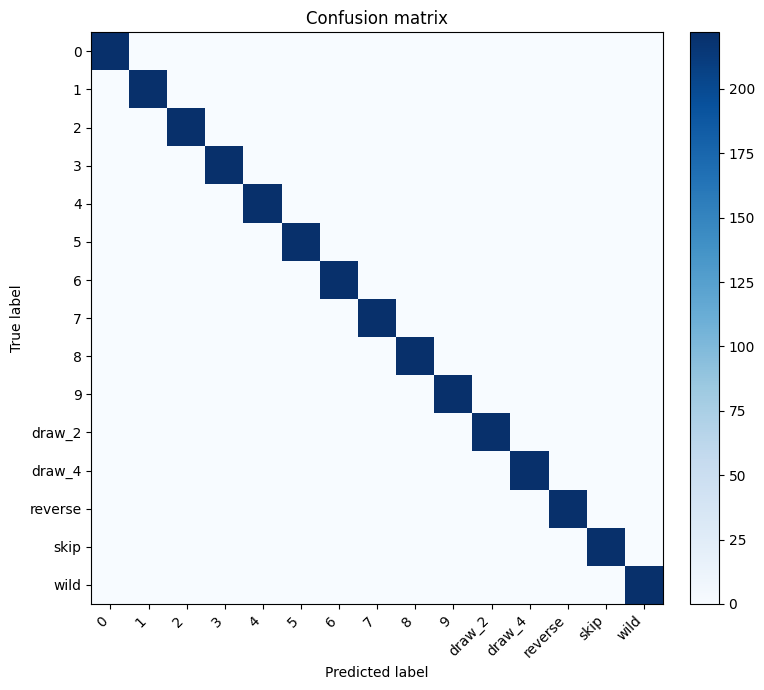

In [23]:
plot_confusion_matrix(confusion_matrix, idx_to_class)
plt.show()


### Performance Analysis

The validation accuracy and F1 score are both equal to `1.0`, which indicates that the CNN correctly classifies every symbol patch in the validation split. 

The confusion matrix supports this result: the predictions lie on the diagonal, meaning that no class is visibly confused with another class. For this dataset, the augmentation strategy seems sufficient to make the model robust to rotation and small shifts in the extracted binary patches.

This result should still be interpreted with the dataset construction in mind. The validation images come from the same symbol-extraction and augmentation process as the training data, so the CNN result mainly validates the symbol classifier once a clean patch has been extracted. In the full image pipeline, errors are more likely to come from segmentation, card grouping, or player attribution than from the CNN itself.


### Training Curves

`plot_history` displays the training and validation accuracy/loss over epochs. The technique here is to compare optimization on the training set with generalization on the validation set: both accuracies should improve, both losses should generally decrease, and the validation curve should not drift away from the training curve.

This gives a visual check for underfitting, overfitting, or unstable training that would not be visible from the final accuracy alone.


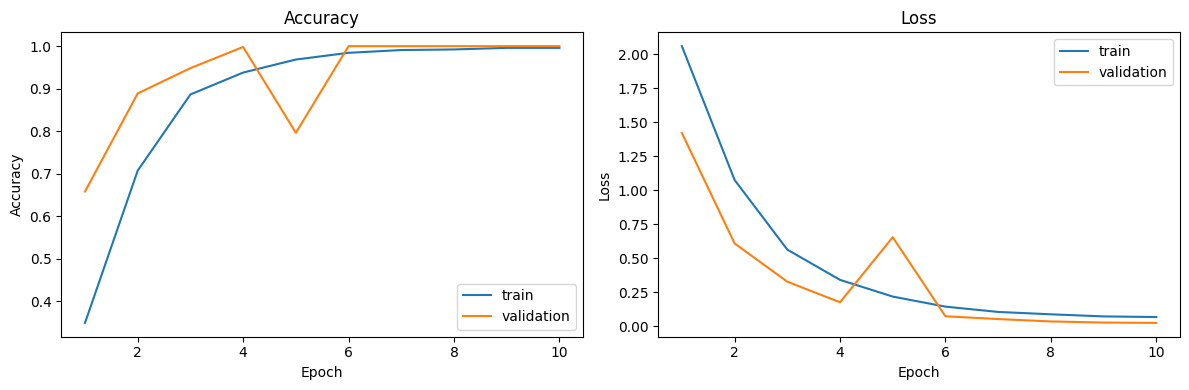

In [24]:
plot_history(history)
plt.show()


### Training Curve Analysis

The curves show that the CNN learns the symbol shapes very quickly. Training accuracy rises from about `0.35` in the first epoch to almost `1.0` by the end, while the training loss decreases steadily across all epochs. This indicates that the model is able to fit the augmented symbol dataset without difficulty.

The validation curve follows the same general trend and reaches `1.0` accuracy from epoch 6 onward. There is one visible instability around epoch 5, where validation loss increases and validation accuracy drops, but the model recovers immediately in the next epoch. Since the validation performance then stays perfect while the loss continues decreasing, this looks like a temporary optimization fluctuation rather than persistent overfitting.

Overall, the training curves are consistent with the final validation metrics: the CNN has converged, and the classification task is well solved once the segmentation pipeline provides clean binary symbol patches.


## CNN Predictions on One Frame

We now apply the classifier to the same frame used in the segmentation section. `Classifier` loads the trained CNN weights, and `show_patch_predictions` calls `build_pipeline_debug`. Inside this call, `detect_and_classify` uses `segmentation.detect_symbols` to extract fixed-size binary patches around the detected corner symbols, then `classifier.classify_patches` applies the CNN to each patch.

The CNN only predicts the symbol shape, not the full UNO card. The full card label is reconstructed afterwards with `card_string`, which combines the segmented card color with the predicted symbol. This separation is useful because color is easier to obtain from classical segmentation, while the CNN focuses on recognizing the symbol shape despite rotation and small translations.

Each displayed patch corresponds to one detected corner symbol. The title shows the reconstructed card label followed by the prediction confidence. At this stage the pipeline has one classified card candidate per detected symbol.


Example frame: L1000993.jpg


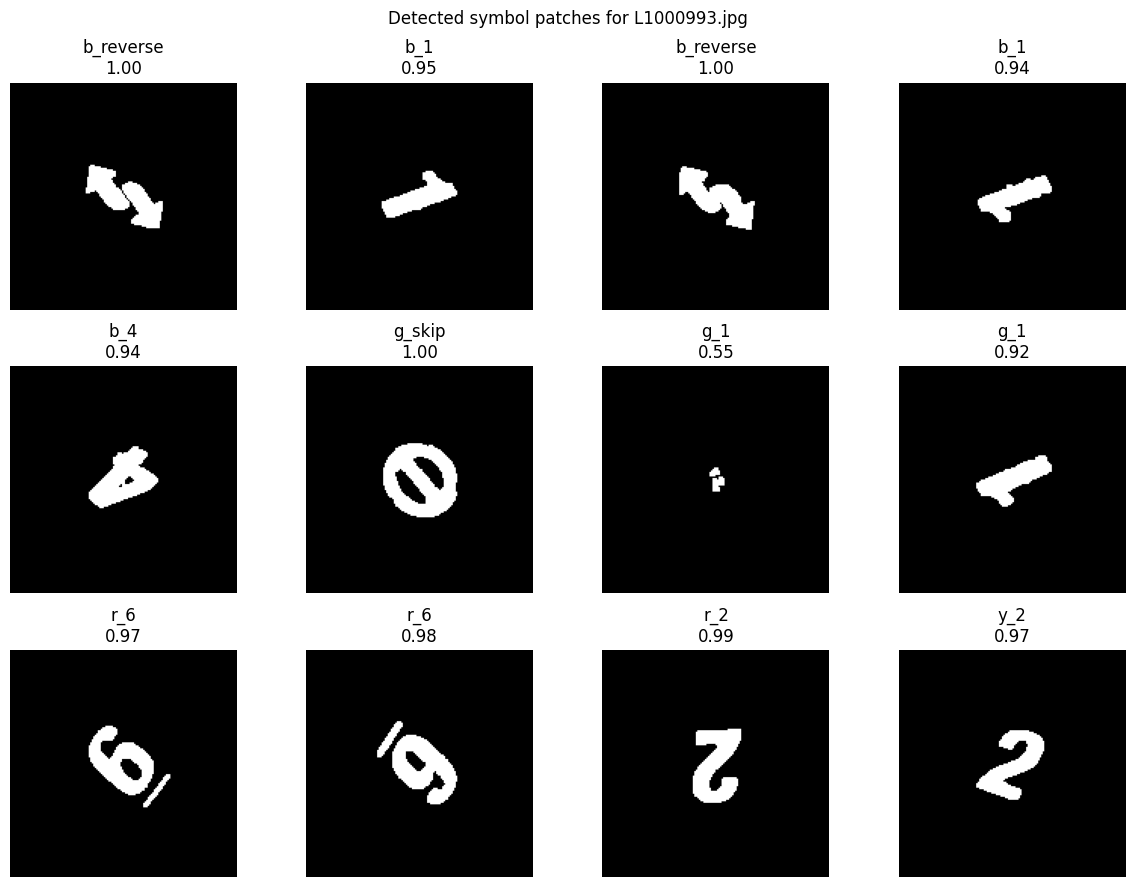

In [25]:
classifier = Classifier(MODEL_PATH, device='auto')
example_frame = IMAGE_PATH
print('Example frame:', example_frame.name)
debug_example = show_patch_predictions(example_frame, classifier)
plt.show()


## Center Card and Player Card Attribution

Once the symbols have been classified, `build_pipeline_debug` calls `assign_players` to attach each detected card to either the center pile or one of the four players. The logic uses geometry: the detections closest to the image center are treated as center-pile candidates, because the played card is expected to be near the middle of the table.

The remaining detections are player-hand candidates. `assign_players` groups their centers with `cluster_points`, then `cluster_2_player_mapping` maps the resulting clusters to the four player anchor regions around the image. The most confident center candidate becomes the central card, while the clustered detections become player cards. `show_pipeline_assignments` visualizes these assignments before duplicate removal, so we can inspect the raw attribution step.


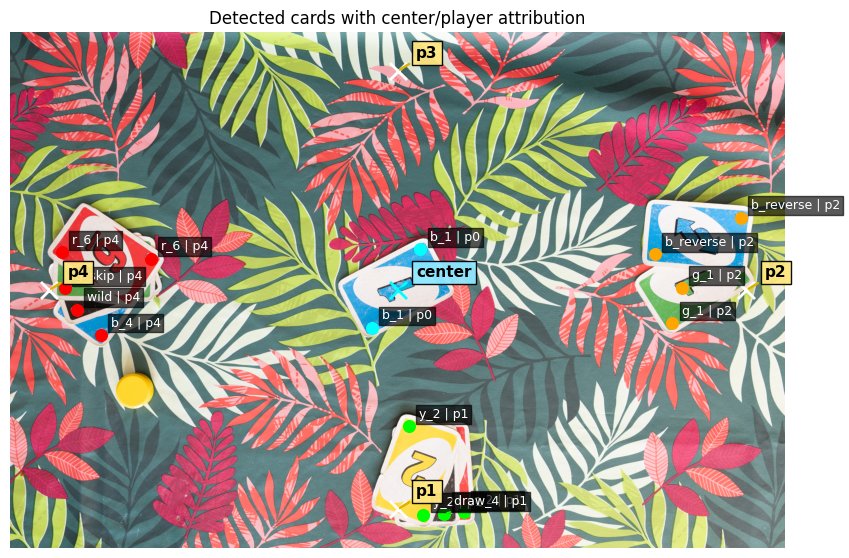

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [26]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=False, show_anchors=True)
plt.show()
debug_example['row']


## Token Attribution to the Active Player

The active-player token is detected separately by the segmentation pipeline with `segmentation.get_token_center`. The logic is again geometric: `active_player_from_token` defines four anchor positions around the image, one for each player, and assigns the token to the nearest anchor by Euclidean distance.

`show_token_assignment` displays the token center and the anchor positions so the decision can be inspected visually. This step is independent of the card labels: the CNN identifies what cards are present, while the token position identifies which player is active.


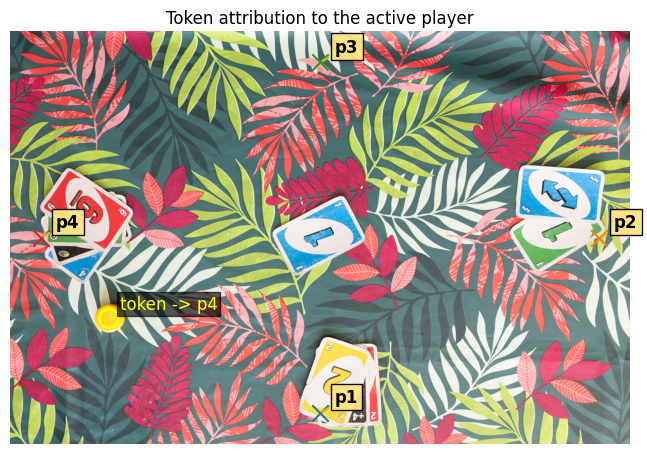

Active player: p4


In [27]:
show_token_assignment(debug_example)
plt.show()
print('Active player:', debug_example['active_player'])

## Duplicate Card Detection Removal

The segmentation can sometimes detect the two printed corner symbols of the same physical card as two separate card detections. This is expected because each UNO card has repeated corner symbols, and both can pass the symbol filter.

After cards have been assigned to players, `sort_player_cards` orders each player's detections in reading order. `collapse_duplicate_detections` then groups detections with the same card label and compares the distance between their centers. If two same-label detections are separated by the expected corner-symbol distance, the second one is removed, because the pair is interpreted as one physical card rather than two identical cards.

The cell below reuses `debug_example`. `show_pipeline_assignments` displays the final player assignments after duplicate removal, and `show_duplicate_collapse` prints the card lists before and after this correction.


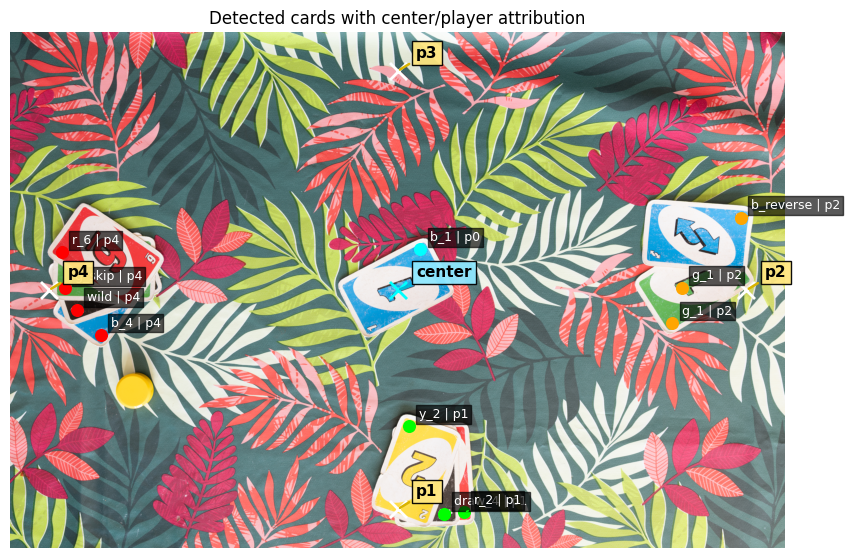

Player 1
  before: ['y_2', 'y_2', 'draw_4', 'r_2']
  after:  ['y_2', 'draw_4', 'r_2']
Player 2
  before: ['b_reverse', 'b_reverse', 'g_1', 'g_1']
  after:  ['b_reverse', 'g_1', 'g_1']
Player 3
  before: ['EMPTY']
  after:  ['EMPTY']
Player 4
  before: ['r_6', 'r_6', 'g_skip', 'wild', 'b_4']
  after:  ['r_6', 'g_skip', 'wild', 'b_4']


In [28]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=True)
plt.show()
show_duplicate_collapse(debug_example)


## Full Pipeline Output

The final cell runs the complete frame pipeline in one call. `build_pipeline_debug` gathers the segmentation output, CNN predictions, center-card assignment, player-card assignment, token attribution, and duplicate removal information. It also calls `prediction_row_for_image`, which converts the intermediate detections into the final submission-style row: one image id, one center card, one active player, and one semicolon-separated card list per player.

`show_full_pipeline_frame` visualizes the result on the original image, while the displayed row shows the exact structured output that can be written to the submission CSV.


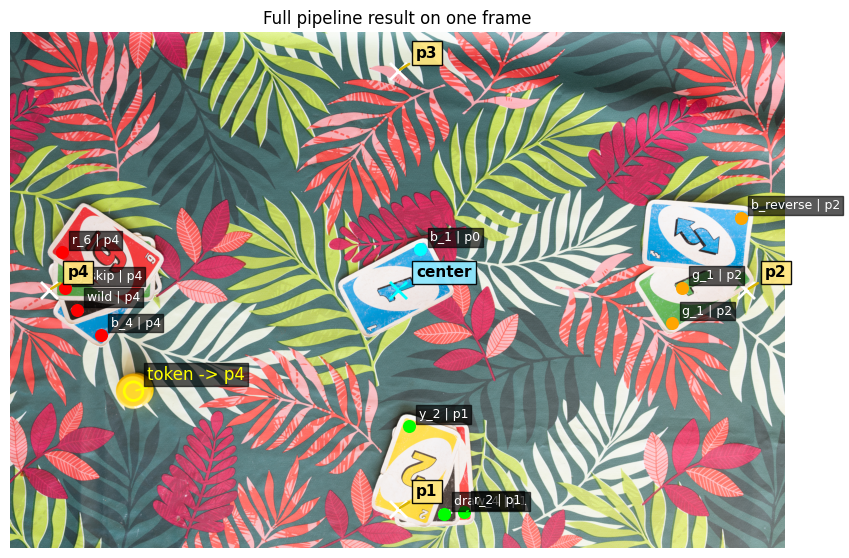

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [29]:
full_debug = build_pipeline_debug(example_frame, classifier)
show_full_pipeline_frame(full_debug, remove_duplicates=True)
plt.show()
full_debug['row']


## Result Analysis

On the validation symbol dataset, the CNN reaches an accuracy and F1 score of `1.0`. This means that, on the prepared validation split of extracted and augmented symbol patches, every patch is classified correctly. The confusion matrix confirms this: the predictions stay on the diagonal, so no symbol class is systematically confused with another one. This perfect score should be interpreted as evidence that the classifier solves the clean patch-recognition subproblem, not as proof that the complete image pipeline is error-free.

On the full demo frame, the end-to-end pipeline detects the center card as `b_7` and assigns the active player to `p2`. The player hands are also reconstructed from the detected symbols and colors. The duplicate-removal step is important here: before correction, several physical cards appear more than once because both corner symbols can be detected separately. After removal, the player hands are cleaner and better match the expected card-level representation.

These results show that the CNN classification stage is reliable when segmentation provides a clean, centered binary patch. The remaining difficulty of the full pipeline mainly comes from earlier and later stages: detecting the correct symbol instances, associating them with the right card, removing duplicate corner detections, and assigning each card to the correct player.
